## Wczytanie bibliotek oraz wstępne przygotowanie zbioru danych AirPassengers

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#reading the dataset
train = pd.read_csv('AirPassengers.csv')

#preprocessing
train.timestamp = pd.to_datetime(train.Month)
train.index = train.timestamp
train.drop('Month',axis = 1, inplace = True)

train.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


# Metody sprawdzania stacjonarności

<Axes: xlabel='Month'>

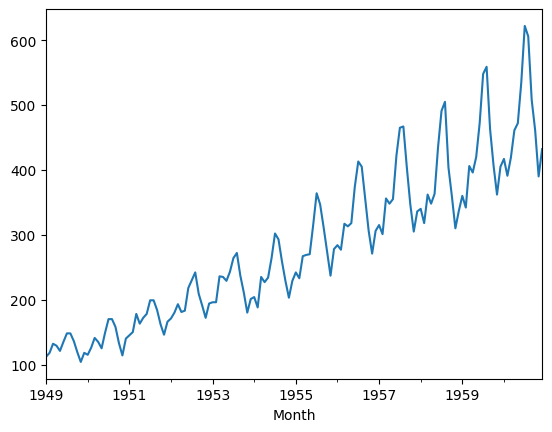

In [11]:
train['#Passengers'].plot()

## Definicja funkcji testu Dickeya-Fullera (ADF) i jego wykonanie

In [12]:
#define function for ADF test
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

#apply adf test on the series
adf_test(train['#Passengers'])

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


### Definicja i wykonanie testu KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

In [13]:
from statsmodels.tsa.stattools import kpss
#define KPSS
def kpss_test(timeseries):
    print ('Results of KPSS Test:')
    kpsstest = kpss(timeseries, regression='c')
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)
kpss_test(train['#Passengers'])

Results of KPSS Test:
Test Statistic           1.651312
p-value                  0.010000
Lags Used                8.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


### Tworzenie szeregu czasowego stacjonarnego


<Axes: xlabel='Month'>

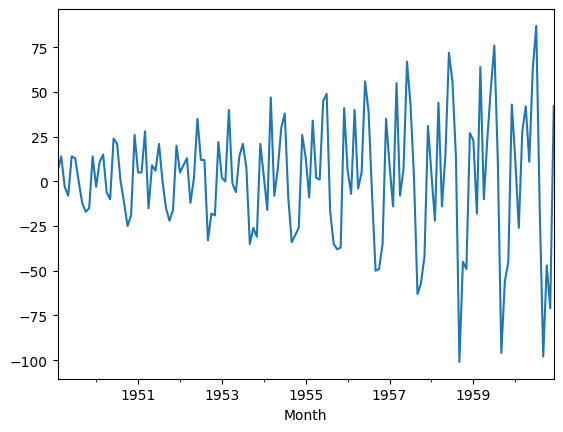

In [14]:
train['#Passengers_diff'] = train['#Passengers'] - train['#Passengers'].shift(1)
train['#Passengers_diff'].dropna().plot()

## Różnicowanie sezonowe


<Axes: xlabel='Month'>

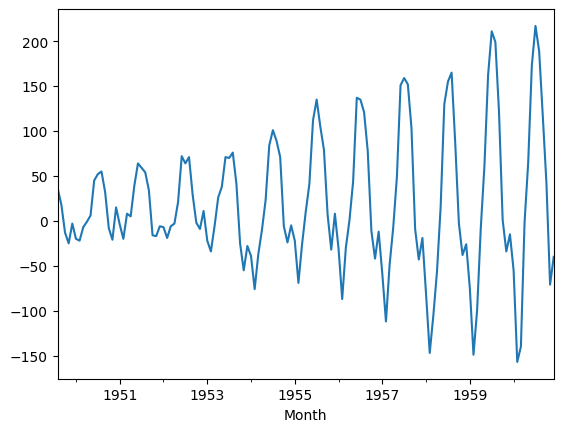

In [15]:
n=7
train['#Passengers_diff'] = train['#Passengers'] - train['#Passengers'].shift(n)
train['#Passengers_diff'].dropna().plot()

### Transformacja: Logarytmowanie danych, obliczenie różnic logarytmicznych i wyrysowanie wykresu

<Axes: xlabel='Month'>

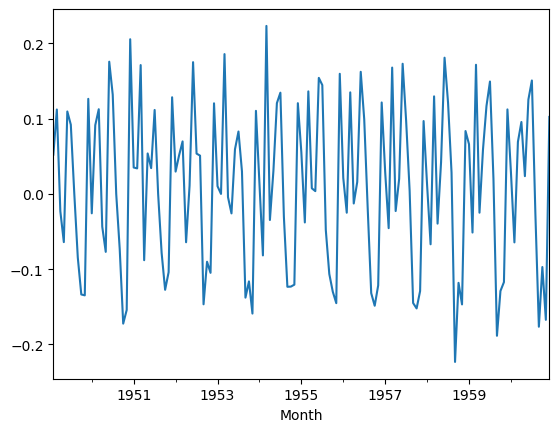

In [16]:
train['#Passengers_log'] = np.log(train['#Passengers'])
train['#Passengers_log_diff'] = train['#Passengers_log'] - train['#Passengers_log'].shift(1)
train['#Passengers_log_diff'].dropna().plot()